In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, 'src')):
    root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(root_dir)

output_fig_dir = os.path.join("results", "figures")
output_tbl_dir = os.path.join("results", "tables")
os.makedirs(output_fig_dir, exist_ok=True)
os.makedirs(output_tbl_dir, exist_ok=True)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,           
    'savefig.dpi': 300,
    'axes.spines.top': False,     
    'axes.spines.right': False,  
    'font.family': 'serif'        
})
COLORS = ['#3498db', '#e74c3c']

def export_table_to_png(df, filename, title=None, col_width=None):
    df_reset = df.reset_index() if df.index.name else df
    
    fig, ax = plt.subplots(figsize=(12, len(df_reset)*0.5 + 1.5))
    ax.axis('off')
    if title:
        ax.set_title(title, fontweight='bold', fontsize=14, pad=20)
    
    table = ax.table(cellText=df_reset.values, 
                     colLabels=df_reset.columns, 
                     cellLoc='left', 
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8) 
    
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
        cell.set_edgecolor('#cccccc')
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')
    plt.close()
    print(f"Tabel disimpan di: {os.path.join(output_tbl_dir, filename)}")

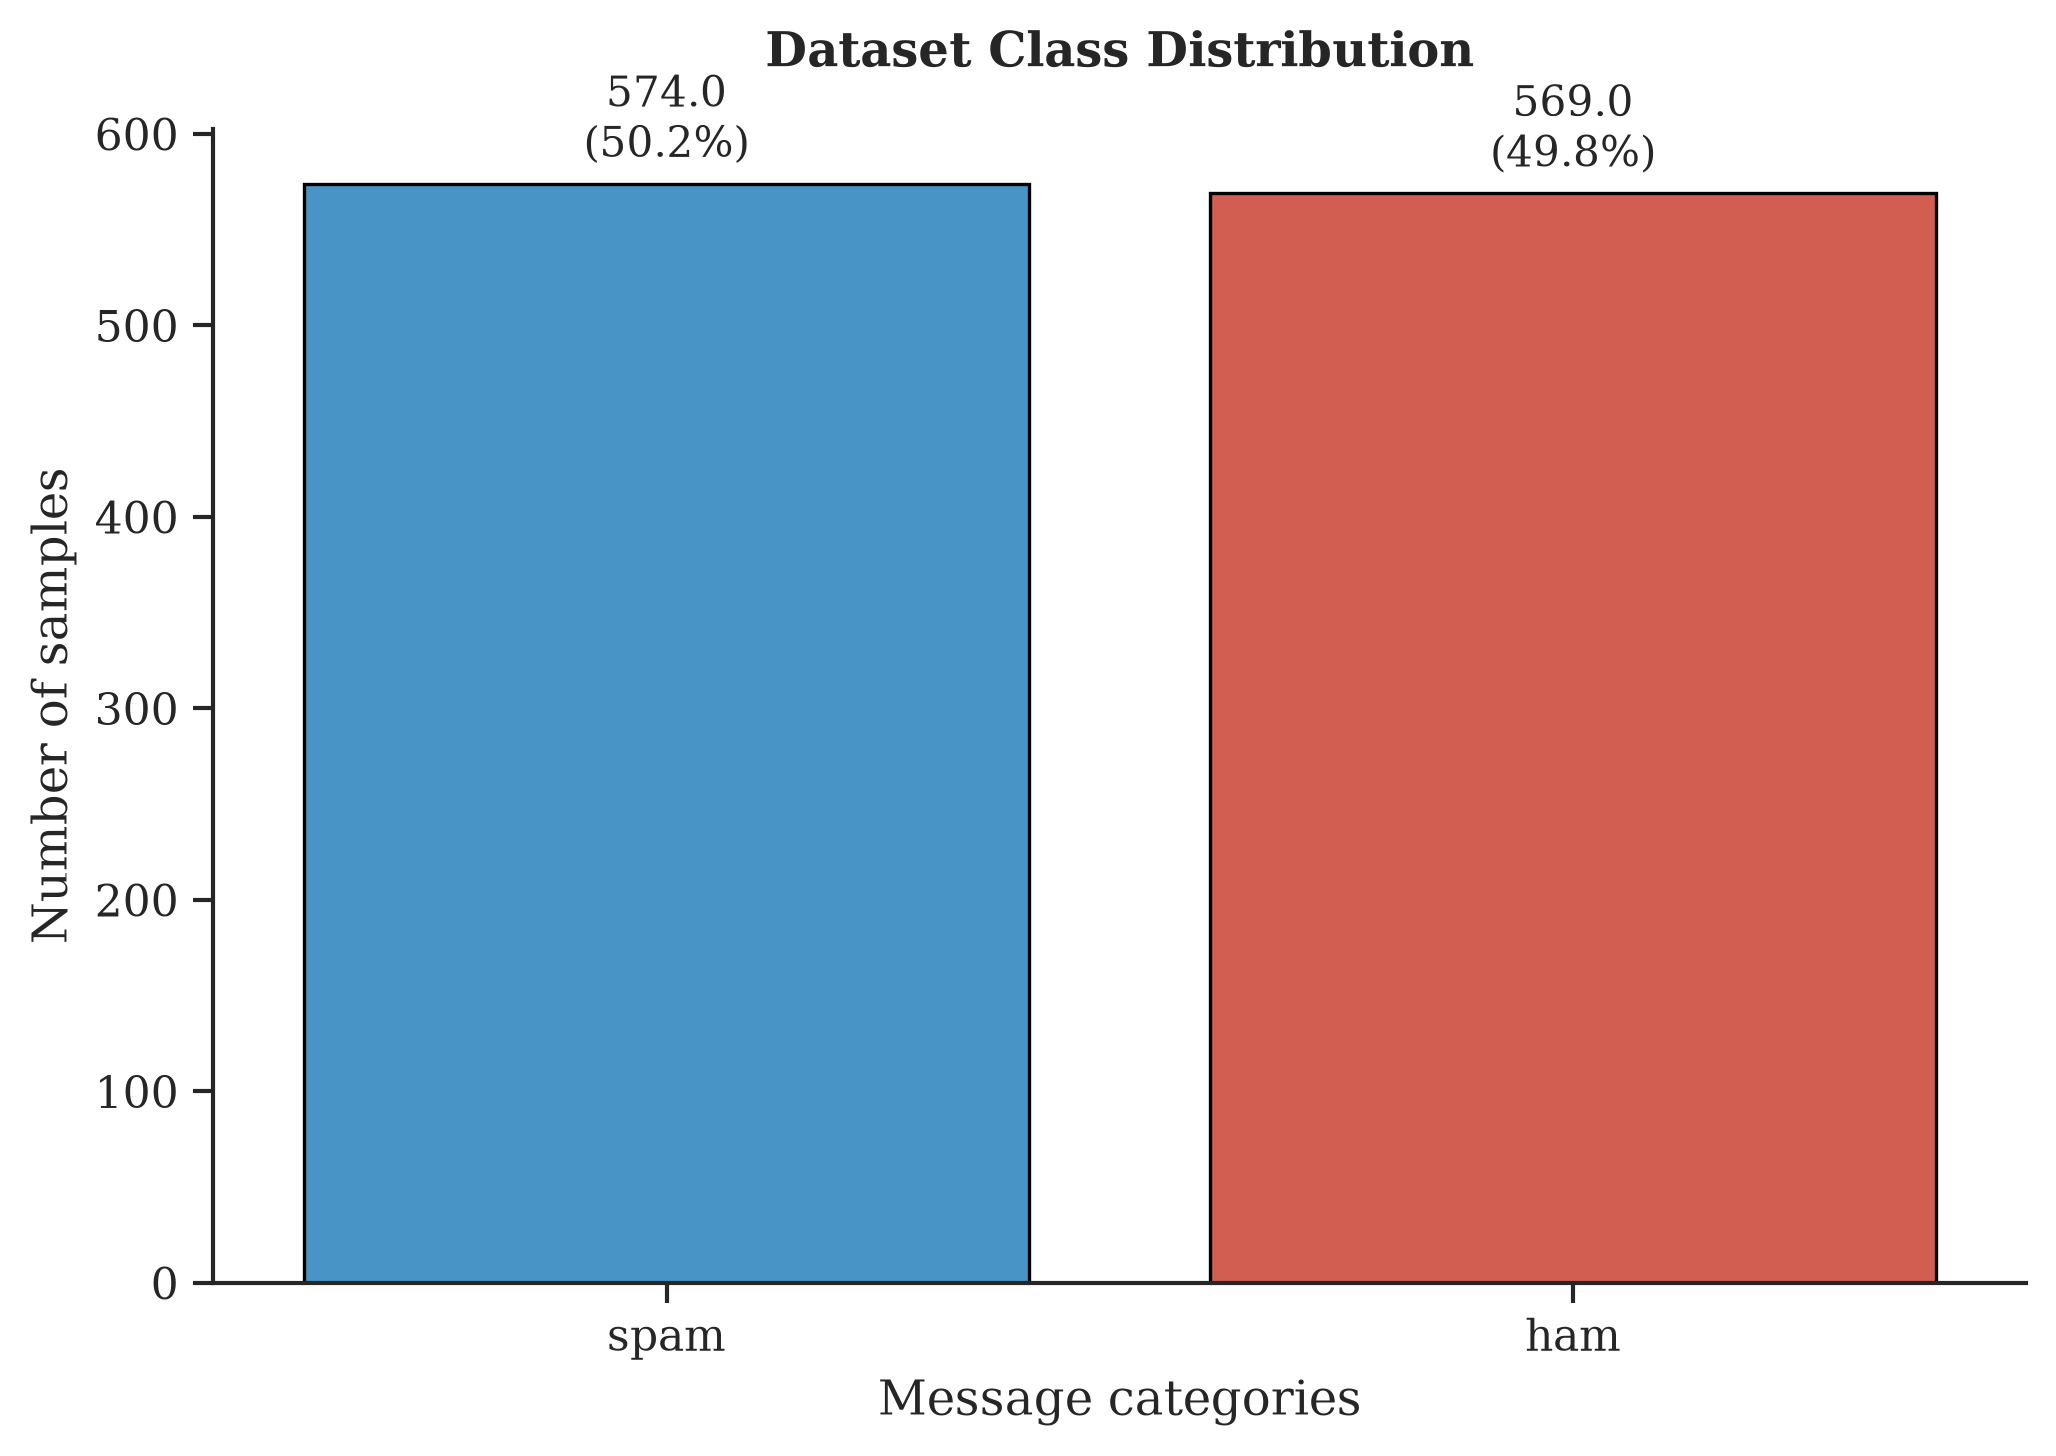

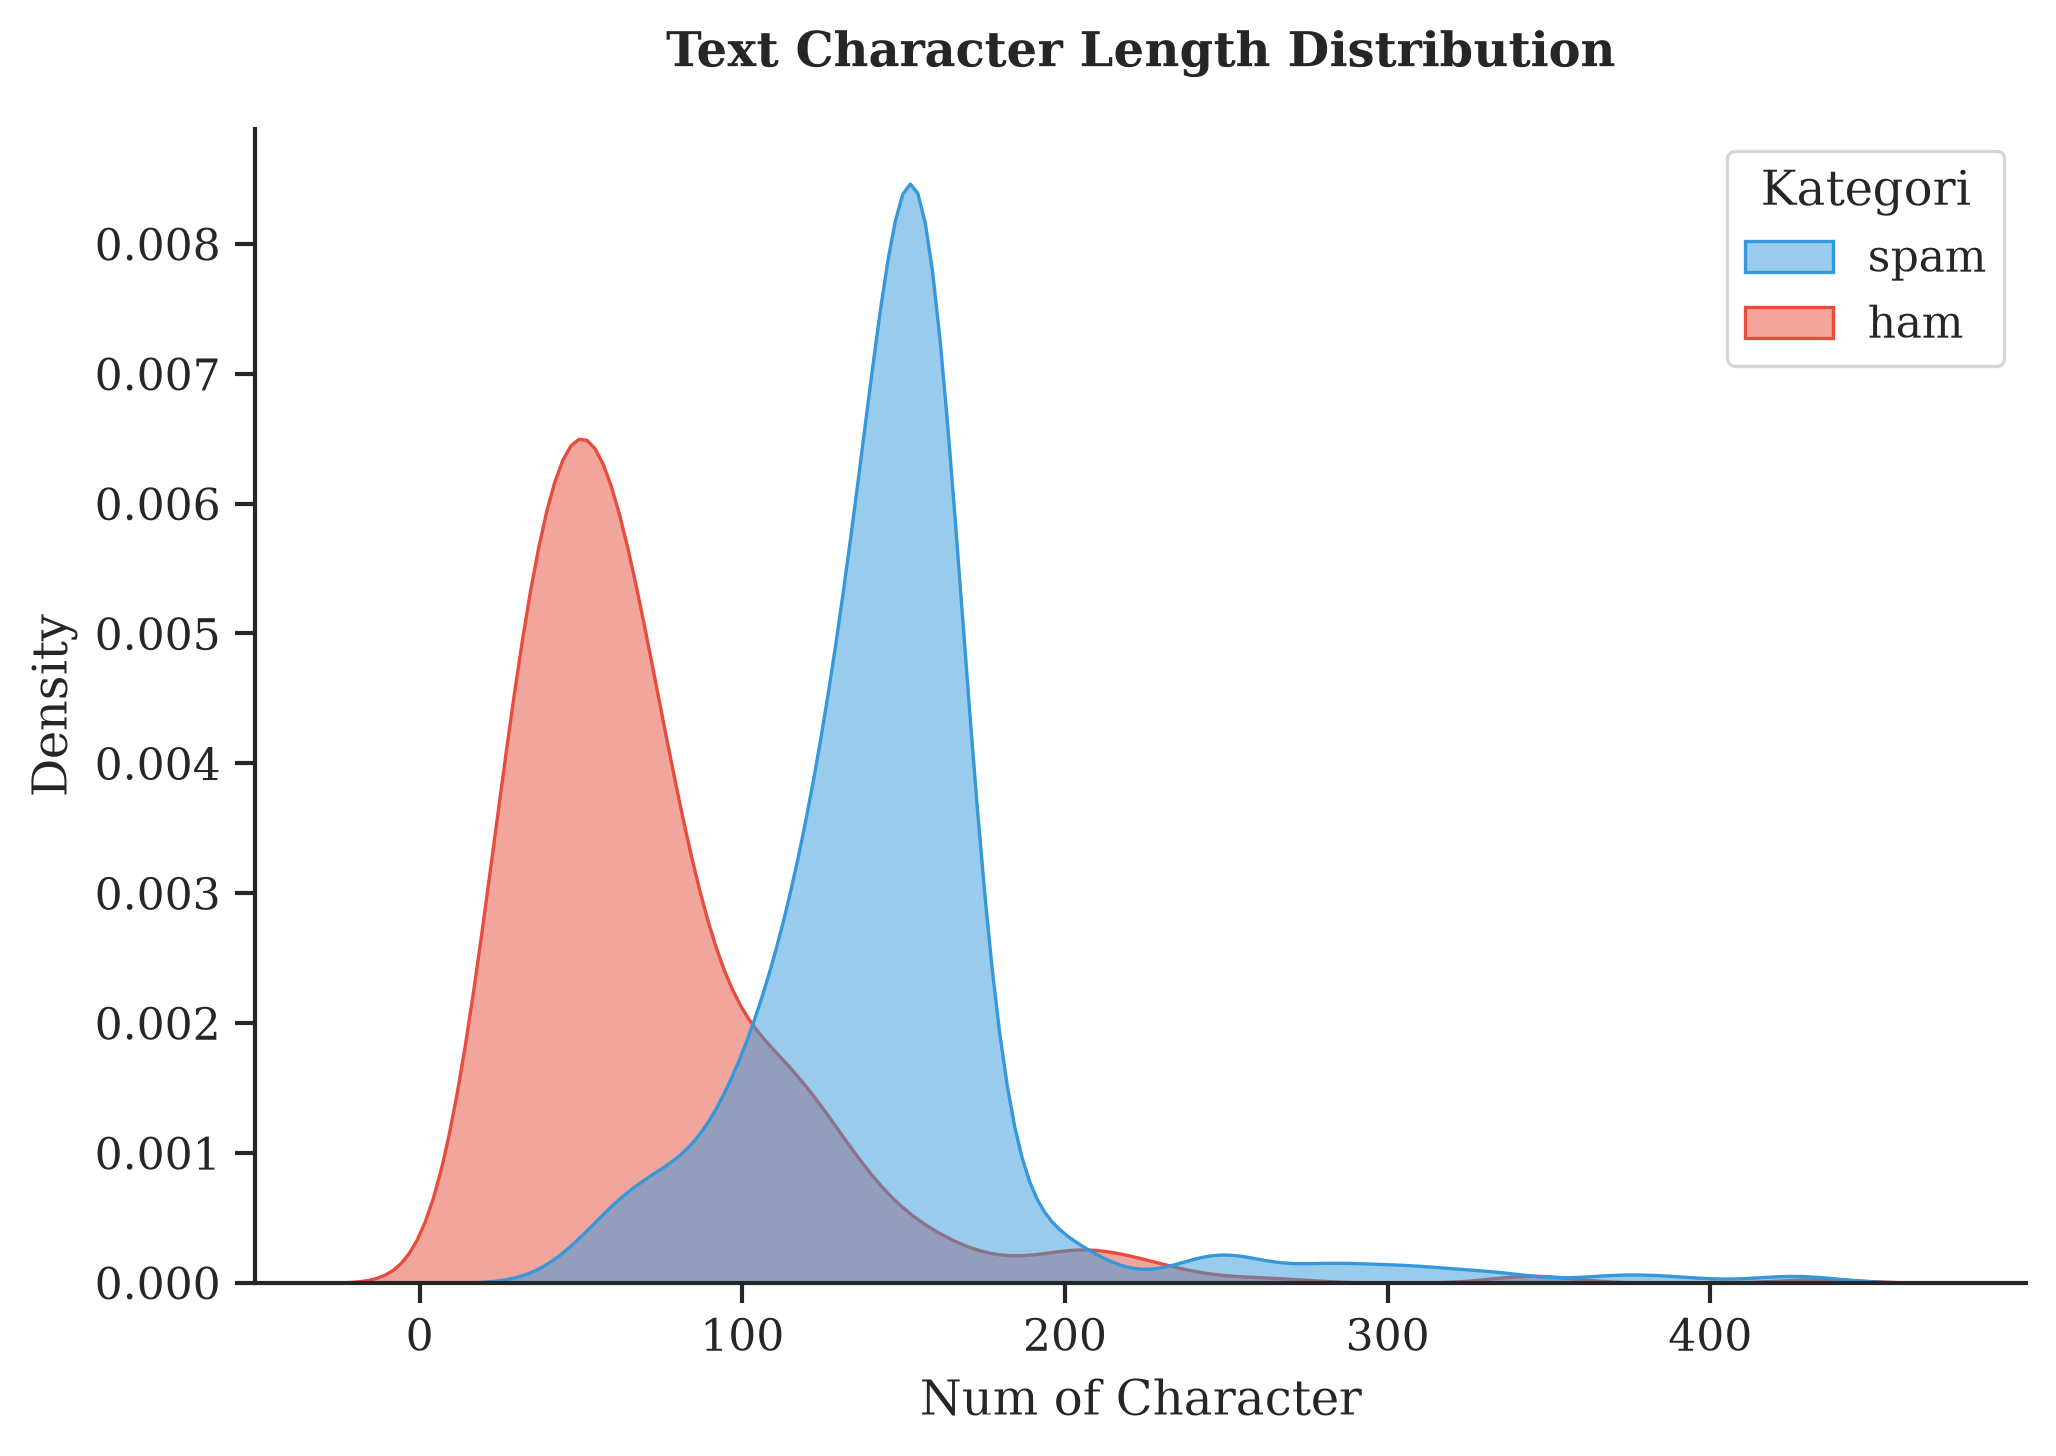

,Karakter_mean,Karakter_median,Karakter_min,Karakter_max,Karakter_std,Kata_mean,Kata_median,Kata_min,Kata_max,Kata_std
Kategori,,,,,,,,,,
ham,70.54,59.0,13,434,46.23,12.12,11.0,2,63,7.23
spam,146.60,149.0,46,431,44.19,21.22,20.0,5,62,6.99


Tabel disimpan di: results\tables\table_eda_text_stats.png


In [2]:
RAW_DATA_PATH = os.path.join("data", "raw", "sms_spam_indo.csv")
df = pd.read_csv(RAW_DATA_PATH)

total_rows = len(df)
df['Karakter'] = df['Pesan'].apply(len)
df['Kata'] = df['Pesan'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Kategori', hue='Kategori', palette=COLORS, edgecolor='black', legend=False)
plt.title('Dataset Class Distribution', fontweight='bold', pad=15)
plt.ylabel('Number of samples')
plt.xlabel('Message categories')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}\n({(height/total_rows)*100:.1f}%)', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, "eda_class_distribution.png"))
plt.show()

plt.figure(figsize=(7, 5))
sns.kdeplot(data=df, x='Karakter', hue='Kategori', fill=True, palette=COLORS, alpha=0.5)
plt.title('Text Character Length Distribution', fontweight='bold', pad=15)
plt.ylabel('Density')
plt.xlabel('Num of Character')

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, "eda_character_distribution.png"))
plt.show()

text_stats = df.groupby('Kategori')[['Karakter', 'Kata']].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
text_stats.columns = ['_'.join(col).strip() for col in text_stats.columns.values]

display(text_stats)
export_table_to_png(text_stats, "table_eda_text_stats.png", title="Text Statistics by Category")

In [ ]:
def plot_and_save_metrics(df_results, metrics_list):
    """
    Membuat grafik bar terpisah untuk setiap metrik dan menyimpannya.
    """
    for metric in metrics_list:
        plt.figure(figsize=(8, 5))
        
        sns.barplot(
            data=df_results, 
            x='Model', 
            y=metric, 
            hue='Technique', 
            palette='mako',
            edgecolor='white'
        )
        
        plt.title(metric, fontweight='bold', fontsize=14, pad=15)
        plt.ylabel('Score')
        plt.xlabel('LLM Architecture')
        plt.xticks(rotation=45)
        
        plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.ylim(0, 1.05) # Standar skor 0-1
        
        plt.tight_layout()
        filename = f"evaluation_{metric.replace(' ', '_').lower()}.png"
        plt.savefig(os.path.join(output_fig_dir, filename))
        plt.show()
        print(f"Grafik {metric} disimpan.")

In [4]:
import glob

def showcase_text_samples(sample_index=0):
    raw_df = pd.read_csv(RAW_DATA_PATH)
    original_spam = raw_df[raw_df['Kategori'] == 'spam'].iloc[sample_index]['Pesan']
    
    showcase_data = []
    
    synth_files = glob.glob("data/augmented/*/synthetic/*.csv")
    
    for file in synth_files:
        basename = os.path.basename(file).replace('.csv', '').replace('synthetic_', '')
        parts = basename.split('_')
        model_name = parts[0]
        technique = parts[1] if len(parts) > 1 else "unknown"
        
        df_synth = pd.read_csv(file)
        
        if len(df_synth) > sample_index:
            synth_text = df_synth.iloc[sample_index]['Pesan']
            showcase_data.append({
                "Model": model_name,
                "Teknik": technique,
                "Variasi Teks": str(synth_text)[:120] + "..."
            })
            
    df_showcase = pd.DataFrame(showcase_data)
    
    df_showcase.loc[-1] = ["Original (Human)", "Ground Truth", str(original_spam)[:120] + "..."]
    df_showcase.index = df_showcase.index + 1
    df_showcase = df_showcase.sort_index()

    display(df_showcase)
    export_table_to_png(df_showcase, "table_text_samples_showcase.png", title="Augmented Text Samples Comparison")

showcase_text_samples(sample_index=0)

,Model,Teknik,Variasi Teks
0,Original (Human),Ground Truth,Plg Yth: Simcard anda mendptkan bonus poin plu...
1,GPT,3.5,Plg Yth: Kartu SIM Anda mendapatkan bonus poin...
2,GPT,3.5,Selamat Siang: Kartu SIM Anda telah memenangka...
3,GPT,3.5,"Halo, Anda telah mendapatkan bonus poin plus-p..."
4,GPT,4.1,Kepada Yth: Simcard Anda mendapatkan bonus poi...
...,...,...,...
64,Gemini,3.5,"Iya deh, aku jg emang pgn ngumpul sih, kapan l..."
65,Gemini,3.5,"Iya deh aku jg emang pengen ngumpul sih, kapan..."
66,Qwen3,8B,"Oke deh, aku juga pengen ngumpul lagi. Kapan y..."
67,Qwen3,8B,"Aku juga mau ngumpul nih, kapan lg? Oke deh :(..."


C:\Users\10\AppData\Local\Temp\ipykernel_6780\4057575535.py:50: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) DejaVu Serif.
  plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')
C:\Users\10\AppData\Local\Temp\ipykernel_6780\4057575535.py:50: UserWarning: Glyph 128532 (\N{PENSIVE FACE}) missing from font(s) DejaVu Serif.
  plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')
C:\Users\10\AppData\Local\Temp\ipykernel_6780\4057575535.py:50: UserWarning: Glyph 129303 (\N{HUGGING FACE}) missing from font(s) DejaVu Serif.
  plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')


Tabel disimpan di: results\tables\table_text_samples_showcase.png
